# Examine a single ABG scan


Default case: `ABG-0001-AC2`. Change the `CASE_ID` variable to examine a different case.

In [74]:
# Imports and configuration
import os
from pathlib import Path
import numpy as np
import nrrd
import matplotlib.pyplot as plt

# Show plots inline when running in Jupyter
%matplotlib inline

ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data' / 'ABG_examples'
OUTPUTS = ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)

print('Root:', ROOT)
print('Data dir:', DATA_DIR)
print('Outputs:', OUTPUTS)

Root: /home/gobi/abigail
Data dir: /home/gobi/abigail/data/ABG_examples
Outputs: /home/gobi/abigail/outputs


In [75]:
# List available cases
cases = [d.name for d in DATA_DIR.iterdir() if d.is_dir()]
print('Available ABG cases:', cases)

Available ABG cases: ['ABG-0015-AC4', 'ABG-0064-MTS', 'ABG-0001-AC2', 'AC2-0003', 'ABG-0029-MTS']


In [76]:
# Choose case ID (change this to examine a different case)
CASE_ID = 'ABG-0064-MTS'
CASE_DIR = DATA_DIR / CASE_ID
assert CASE_DIR.exists(), f'Case dir not found: {CASE_DIR}'
print('Case dir:', CASE_DIR)

# List files in the case directory
print('\nFiles in case directory:')
for f in sorted(CASE_DIR.iterdir()):
    print(f'  {f.name}')

Case dir: /home/gobi/abigail/data/ABG_examples/ABG-0064-MTS

Files in case directory:
  2025-10-07-Scene.mrml
  2025-10-07-Scene.png
  3D_Brain_View_FLAIR_SHC - as DWI Volume.nhdr
  3D_Brain_View_FLAIR_SHC - as DWI Volume.raw.gz
  601 MR DWI_TRA - 2 frames Volume Sequence by _5XEW.seq.nrrd
  CORT1w - as DWI Volume.nhdr
  CORT1w - as DWI Volume.raw.gz
  DWI.nrrd
  FLAIR.nhdr
  FLAIR.raw.gz
  FLAIR_COR - as DWI Volume.nhdr
  FLAIR_COR - as DWI Volume.raw.gz
  FLAIR_SAG - as DWI Volume.nhdr
  FLAIR_SAG - as DWI Volume.raw.gz
  SAG T1w - as DWI Volume.nhdr
  SAG T1w - as DWI Volume.raw.gz
  Segmentation.seg.nrrd
  T1W_3D_4mm - as DWI Volume.nhdr
  T1W_3D_4mm - as DWI Volume.raw.gz
  T1W_3D_TFE - as DWI Volume.nhdr
  T1W_3D_TFE - as DWI Volume.raw.gz
  T1c.nhdr
  T1c.raw.gz
  T2W_TSE - as DWI Volume.nhdr
  T2W_TSE - as DWI Volume.raw.gz
  dADC - as DWI Volume.nhdr
  dADC - as DWI Volume.raw.gz


In [77]:
# Auto-detect available MRI sequences (supports both .nrrd and .nhdr formats)
def find_file(case_dir, patterns):
    """Find first matching file from a list of glob patterns."""
    for pattern in patterns:
        matches = list(case_dir.glob(pattern))
        if matches:
            return matches[0]
    return None

# Search for standard MRI sequences with flexible file extensions
FILES = {
    't1c': find_file(CASE_DIR, ['T1c.nrrd', 'T1c.nhdr', 'T1W_3D_TFE*.nhdr', 'CORT1w*.nhdr']),
    't1': find_file(CASE_DIR, ['T1.nrrd', 'T1.nhdr', 'SAG T1w*.nhdr']),
    't2': find_file(CASE_DIR, ['T2.nrrd', 'T2.nhdr', 'T2W_TSE*.nhdr']),
    'flair': find_file(CASE_DIR, ['FLAIR.nrrd', 'FLAIR.nhdr', '3D_Brain_View_FLAIR*.nhdr']),
    'flair_transformed': find_file(CASE_DIR, ['FLAIR-transformed.nrrd']),
    'seg': find_file(CASE_DIR, ['Segmentation.seg.nrrd']),
    'adc': find_file(CASE_DIR, ['ADC.nhdr', 'ADC.nrrd', 'dADC*.nhdr']),
    'dwi': find_file(CASE_DIR, ['DWI.nrrd', 'DWI.nhdr']),
}

print('File detection results:')
for k, p in FILES.items():
    if p is not None:
        print(f'  {k}: {p.name} ✓')
    else:
        print(f'  {k}: not found')

File detection results:
  t1c: T1c.nhdr ✓
  t1: SAG T1w - as DWI Volume.nhdr ✓
  t2: T2W_TSE - as DWI Volume.nhdr ✓
  flair: FLAIR.nhdr ✓
  flair_transformed: not found
  seg: Segmentation.seg.nrrd ✓
  adc: dADC - as DWI Volume.nhdr ✓
  dwi: DWI.nrrd ✓


In [78]:
# Load available images into memory (uses pynrrd)
imgs = {}
headers = {}

for k, p in FILES.items():
    if p is not None and p.exists():
        try:
            data, header = nrrd.read(str(p))
            imgs[k] = data
            headers[k] = header
            print(f'Loaded {k}: shape={data.shape}, dtype={data.dtype}')
        except Exception as e:
            print(f'{k}: Error loading - {e}')
            imgs[k] = None
            headers[k] = None
    else:
        imgs[k] = None
        headers[k] = None

# Summary
loaded = [k for k, v in imgs.items() if v is not None]
print(f'\nSuccessfully loaded {len(loaded)} modalities: {", ".join(loaded)}')

Loaded t1c: shape=(256, 256, 35), dtype=int16
Loaded t1: shape=(256, 256, 24), dtype=int16
Loaded t2: shape=(512, 512, 34), dtype=int16
Loaded flair: shape=(240, 240, 50), dtype=int16
Loaded seg: shape=(288, 288, 23), dtype=uint8
Loaded adc: shape=(288, 288, 23), dtype=int16
Loaded dwi: shape=(288, 288, 23), dtype=float64

Successfully loaded 7 modalities: t1c, t1, t2, flair, seg, adc, dwi


In [79]:
# Display NRRD header info for a selected modality
mod_to_inspect = 't1c' if headers.get('t1c') is not None else 't1'
if headers.get(mod_to_inspect) is not None:
    print(f'Header info for {mod_to_inspect}:')
    for key, val in headers[mod_to_inspect].items():
        print(f'  {key}: {val}')

Header info for t1c:
  type: short
  dimension: 3
  space: right-anterior-superior
  sizes: [256 256  35]
  space directions: [[-0.90350615 -0.02424426  0.02666292]
 [ 0.01577801 -0.86760241 -0.25424235]
 [ 0.16124234 -1.261952    4.31641959]]
  kinds: ['domain', 'domain', 'domain']
  endian: little
  encoding: gzip
  space origin: [112.00214507 145.98434691 -61.58688036]
  measurement frame: [[-0.99920549 -0.02681221  0.02948706]
 [ 0.01744922 -0.95949883 -0.2811717 ]
 [ 0.03583163 -0.28043378  0.95920435]]
  data file: T1c.raw.gz
  DICOM_0008_0060_Modality: MR
  DICOM_0008_0070_Manufacturer: Philips Medical Systems
  DICOM_0008_1090_ManufacturerModelName: Achieva
  DICOM_0018_0022_ScanOptions: OTHER
  DICOM_0018_0023_MRAcquisitionType: 3D
  DICOM_0018_0080_RepetitionTime: 8.29539966583252
  DICOM_0018_0081_EchoTime: 3.873
  DICOM_0018_0083_NumberOfAverages: 1
  DICOM_0018_0087_MagneticFieldStrength: 3
  DICOM_0018_1020_SoftwareVersions: 3.2.3
  DICOM_0018_1314_FlipAngle: 8
  DWMRI_b-

In [80]:
# Display orthogonal slices (axial, coronal, sagittal) and overlay seg (if present)
def plot_orthogonal(img_arr, seg_arr=None, slice_indices=None, spacing=None, cmap='gray', vmin=None, vmax=None, figsize=(12,4), title_prefix=''):
    """Plot orthogonal slices of a 3D image with optional segmentation overlay.
    
    Args:
        spacing: tuple of (sx, sy, sz) voxel spacing to set correct aspect ratio
    """
    # img_arr: numpy array - handle different axis orders
    if img_arr.ndim == 4:
        # For 4D arrays, take the first volume
        img_arr = img_arr[..., 0] if img_arr.shape[-1] < img_arr.shape[0] else img_arr[0, ...]
    
    shape = img_arr.shape
    if slice_indices is None:
        slice_indices = (shape[2]//2, shape[1]//2, shape[0]//2)  # axial, coronal, sagittal
    
    # Default spacing if not provided
    if spacing is None:
        spacing = (1.0, 1.0, 1.0)
    sx, sy, sz = spacing
    
    axial, coronal, sagittal = slice_indices
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # axial: XY plane at z=axial -> aspect = sy/sx
    axes[0].imshow(np.rot90(img_arr[:, :, axial]), cmap=cmap, vmin=vmin, vmax=vmax, aspect=sy/sx)
    axes[0].set_title(f'{title_prefix} Axial z={axial}')
    axes[0].axis('off')
    
    # coronal: XZ plane at y=coronal -> aspect = sz/sx
    axes[1].imshow(np.rot90(img_arr[:, coronal, :]), cmap=cmap, vmin=vmin, vmax=vmax, aspect=sz/sx)
    axes[1].set_title(f'{title_prefix} Coronal y={coronal}')
    axes[1].axis('off')
    
    # sagittal: YZ plane at x=sagittal -> aspect = sz/sy
    axes[2].imshow(np.rot90(img_arr[sagittal, :, :]), cmap=cmap, vmin=vmin, vmax=vmax, aspect=sz/sy)
    axes[2].set_title(f'{title_prefix} Sagittal x={sagittal}')
    axes[2].axis('off')
    
    # overlay segmentation if provided
    if seg_arr is not None:
        from matplotlib import colors
        
        # Handle 4D segmentation arrays
        if seg_arr.ndim == 4:
            seg_arr = seg_arr[..., 0] if seg_arr.shape[-1] < seg_arr.shape[0] else seg_arr[0, ...]
        
        # Get unique labels
        unique_labels = np.unique(seg_arr)
        unique_labels = unique_labels[unique_labels > 0]  # exclude background
        print(f'Segmentation labels: {unique_labels}')
        
        # Create colormap for segmentation
        seg_colors = ['none', 'yellow', 'cyan', 'red', 'green', 'magenta']
        cmap_seg = colors.ListedColormap(seg_colors[:len(unique_labels)+1])
        
        # Overlay on all views with correct aspect ratios
        aspects = [sy/sx, sz/sx, sz/sy]
        for ax_idx, (ax, sl, asp) in enumerate(zip(axes, [seg_arr[:,:,axial], seg_arr[:,coronal,:], seg_arr[sagittal,:,:]], aspects)):
            seg_display = sl.copy()
            # Normalize labels to consecutive integers for colormap
            seg_idx = np.zeros_like(seg_display, dtype=int)
            for i, label in enumerate(unique_labels, 1):
                seg_idx[seg_display == label] = i
            ax.imshow(np.rot90(seg_idx), cmap=cmap_seg, alpha=0.5, interpolation='nearest', vmin=0, vmax=len(unique_labels), aspect=asp)
    
    plt.tight_layout()
    return fig

Using modality: dwi
Image shape for visualization: (288, 288, 23)
Segmentation shape: (288, 288, 23)
Voxel spacing (x, y, z): (np.float64(0.8327496384700778), np.float64(0.7741515522158358), np.float64(5.572214473377553))
Tumor-centered slices: axial z=19, coronal y=171, sagittal x=119
Segmentation labels: [1 2]


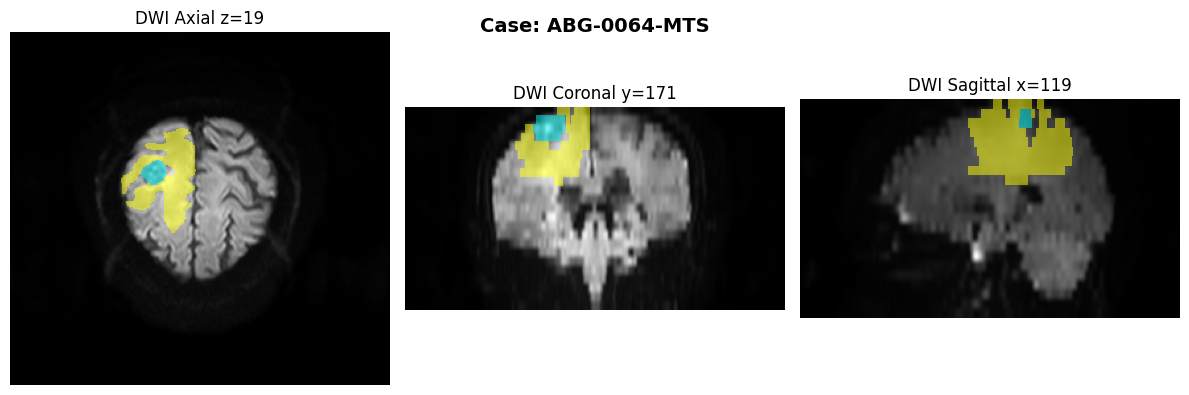

In [81]:
# Pick a modality to show (prefer t1c, fallback to others)
mod = None
for m in ('t1c', 't1', 'flair', 't2', 'dwi', 'adc', 'flair_transformed'):
    if imgs.get(m) is not None:
        mod = m
        break

# Pick your modality here
mod = 'dwi'   # Comment out if you want to choose by the default order

assert mod is not None, 'No modality found for visualization'
print(f'Using modality: {mod}')

img_arr = imgs[mod]
seg_arr = imgs.get('seg')

# Handle potential 4D arrays
if img_arr.ndim == 4:
    print(f'Original shape: {img_arr.shape} (4D), using first volume')
    img_arr = img_arr[..., 0] if img_arr.shape[-1] < img_arr.shape[0] else img_arr[0, ...]

if seg_arr is not None and seg_arr.ndim == 4:
    seg_arr = seg_arr[..., 0] if seg_arr.shape[-1] < seg_arr.shape[0] else seg_arr[0, ...]

print(f'Image shape for visualization: {img_arr.shape}')
if seg_arr is not None:
    print(f'Segmentation shape: {seg_arr.shape}')

# Extract voxel spacing from header
spacing = (1.0, 1.0, 1.0)  # default
if headers.get(mod) is not None:
    header = headers[mod]
    # NRRD stores spacing in 'space directions' or 'spacings'
    if 'space directions' in header:
        dirs = header['space directions']
        # Extract diagonal elements (spacing along each axis)
        spacing = tuple(abs(dirs[i][i]) for i in range(3))
    elif 'spacings' in header:
        spacing = tuple(header['spacings'][:3])
    print(f'Voxel spacing (x, y, z): {spacing}')

# Choose slice indices based on tumor location
if seg_arr is not None and seg_arr.max() > 0 and seg_arr.shape == img_arr.shape:
    # Only use tumor-centered slicing if shapes match
    seg_binary = (seg_arr > 0).astype(int)
    
    # Sum across each axis to find where tumor is most visible
    # z_sum = seg_binary.sum(axis=(0, 1))  # sum over x,y -> z profile
    # y_sum = seg_binary.sum(axis=(0, 2))  # sum over x,z -> y profile
    # x_sum = seg_binary.sum(axis=(1, 2))  # sum over y,z -> x profile

    z_sum = seg_arr.sum(axis=(0, 1))  # sum over x,y -> z profile
    y_sum = seg_arr.sum(axis=(0, 2))  # sum over x,z -> y profile
    x_sum = seg_arr.sum(axis=(1, 2))  # sum over y,z -> x profile
    
    # Find slice with maximum tumor in each direction
    z_max = np.argmax(z_sum)
    y_max = np.argmax(y_sum)
    x_max = np.argmax(x_sum)
    
    slice_indices = (z_max, y_max, x_max)
    print(f'Tumor-centered slices: axial z={z_max}, coronal y={y_max}, sagittal x={x_max}')
else:
    # Default to middle slices if no segmentation or shape mismatch
    slice_indices = (img_arr.shape[2]//2, img_arr.shape[1]//2, img_arr.shape[0]//2)
    print(f'Using middle slices: axial z={slice_indices[0]}, coronal y={slice_indices[1]}, sagittal x={slice_indices[2]}')
    if seg_arr is not None and seg_arr.shape != img_arr.shape:
        print(f'Warning: Segmentation shape {seg_arr.shape} != Image shape {img_arr.shape}')
        print(f'Segmentation overlay will be disabled for this modality')
        seg_arr = None  # Disable overlay if shapes don't match

fig = plot_orthogonal(
    img_arr, 
    seg_arr=seg_arr, 
    slice_indices=slice_indices, 
    spacing=spacing,
    title_prefix=mod.upper()
)
fig.suptitle(f'Case: {CASE_ID}', fontsize=14, fontweight='bold', y=0.98)
plt.show()

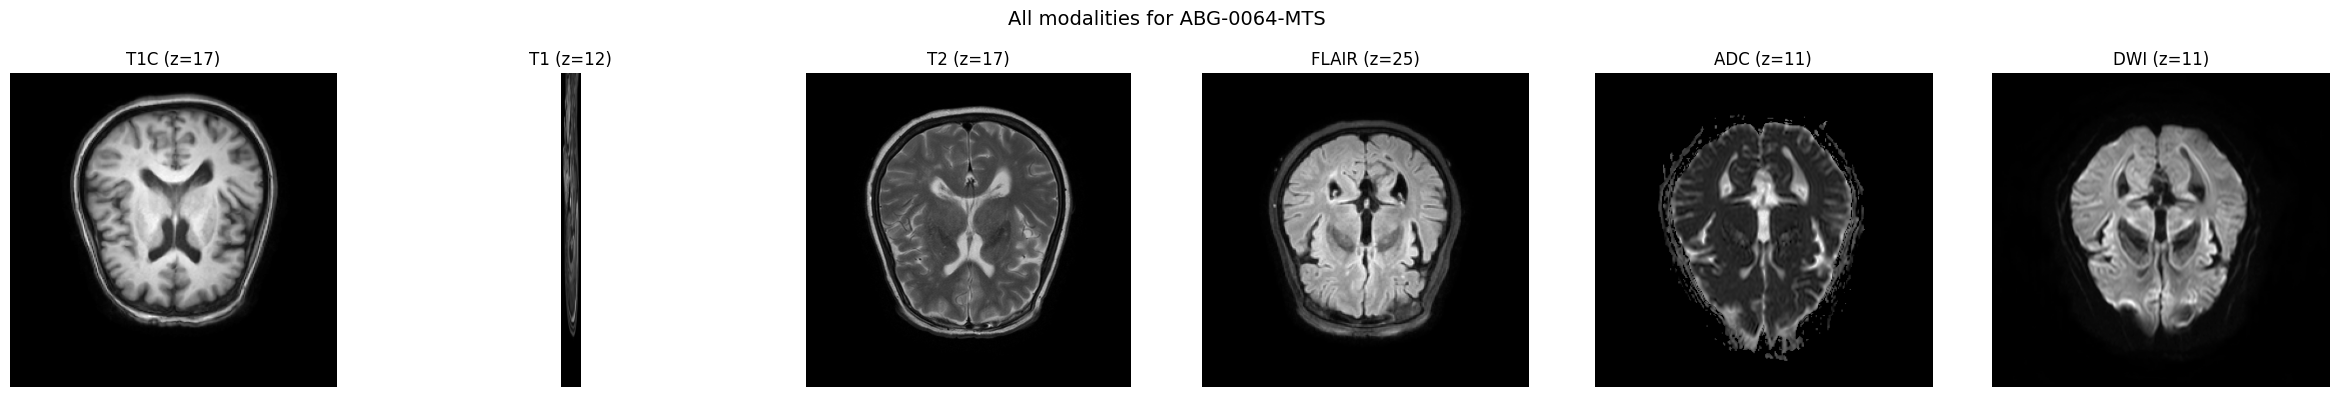

In [82]:
# Display all available modalities side by side (axial view)
available_mods = [k for k, v in imgs.items() if v is not None and k != 'seg']
n_mods = len(available_mods)

if n_mods > 0:
    fig, axes = plt.subplots(1, n_mods, figsize=(4*n_mods, 4))
    if n_mods == 1:
        axes = [axes]
    
    for ax, mod_name in zip(axes, available_mods):
        arr = imgs[mod_name]
        if arr.ndim == 4:
            arr = arr[..., 0] if arr.shape[-1] < arr.shape[0] else arr[0, ...]
        
        # Get spacing for this modality
        mod_spacing = (1.0, 1.0, 1.0)
        if headers.get(mod_name) is not None:
            h = headers[mod_name]
            if 'space directions' in h:
                dirs = h['space directions']
                mod_spacing = tuple(abs(dirs[i][i]) for i in range(3))
            elif 'spacings' in h:
                mod_spacing = tuple(h['spacings'][:3])
        sx, sy, sz = mod_spacing
        
        # Show middle axial slice with correct aspect
        z_mid = arr.shape[2] // 2
        ax.imshow(np.rot90(arr[:, :, z_mid]), cmap='gray', aspect=sy/sx)
        ax.set_title(f'{mod_name.upper()} (z={z_mid})')
        ax.axis('off')
    
    plt.suptitle(f'All modalities for {CASE_ID}', fontsize=14)
    plt.tight_layout()
    plt.show()

In [83]:
# Examine segmentation details
if seg_arr is not None:
    print('Segmentation array info:')
    print(f'  Shape: {seg_arr.shape}')
    print(f'  Dtype: {seg_arr.dtype}')
    print(f'  Unique values: {np.unique(seg_arr)}')
    print(f'  Value counts:')
    for val in np.unique(seg_arr):
        count = np.sum(seg_arr == val)
        print(f'    {val}: {count} voxels ({100*count/seg_arr.size:.2f}%)')
else:
    print('No segmentation available for this case')

Segmentation array info:
  Shape: (288, 288, 23)
  Dtype: uint8
  Unique values: [0 1 2]
  Value counts:
    0: 1890781 voxels (99.11%)
    1: 15863 voxels (0.83%)
    2: 1068 voxels (0.06%)


In [84]:
# Create a 3D mesh of the segmentation using marching cubes and visualize with plotly
# Using step_size to reduce mesh complexity and file size
if seg_arr is not None and seg_arr.max() > 0:
    from skimage import measure
    import plotly.graph_objects as go
    
    # Handle 4D segmentation
    seg_3d = seg_arr
    if seg_3d.ndim == 4:
        seg_3d = seg_3d[..., 0] if seg_3d.shape[-1] < seg_3d.shape[0] else seg_3d[0, ...]
    
    # step_size controls mesh resolution: higher = fewer triangles, smaller file
    # step_size=1 is full resolution, step_size=2 reduces by ~4x, step_size=4 by ~16x
    STEP_SIZE = 2  # Adjust: 1=full, 2=good balance, 4=fast/small
    
    # Use marching cubes with step_size to reduce mesh complexity
    verts, faces, normals, values = measure.marching_cubes(
        seg_3d.astype(float), 
        level=0.5,
        step_size=STEP_SIZE
    )
    
    # IMPORTANT: Scale vertices by voxel spacing for correct 3D proportions!
    # Without this, the mesh looks squished if voxels aren't cubes
    verts_scaled = verts.copy()
    verts_scaled[:, 0] *= spacing[0]  # X
    verts_scaled[:, 1] *= spacing[1]  # Y
    verts_scaled[:, 2] *= spacing[2]  # Z
    
    print(f'Segmentation mesh: {len(verts)} vertices, {len(faces)} faces (step_size={STEP_SIZE})')
    print(f'Applied voxel spacing: {spacing}')
    
    # Create a 3D plotly figure
    fig = go.Figure(data=[
        go.Mesh3d(
            x=verts_scaled[:,0], y=verts_scaled[:,1], z=verts_scaled[:,2],
            i=faces[:,0], j=faces[:,1], k=faces[:,2],
            color='lightpink', opacity=0.5,
            name='Segmentation'
        )
    ])
    fig.update_layout(scene=dict(
        xaxis_title='X (mm)',
        yaxis_title='Y (mm)',
        zaxis_title='Z (mm)',
        aspectmode='data'
    ), title=f'3D Mesh of Segmentation for {CASE_ID}')
    
    # Save to HTML file
    output_html = OUTPUTS / f'mesh_{CASE_ID}.html'
    fig.write_html(str(output_html))
    print(f'3D mesh saved to {output_html}')
    fig.show()
else:
    print('No segmentation data available for 3D mesh')

Segmentation mesh: 2568 vertices, 5024 faces (step_size=2)
Applied voxel spacing: (np.float64(0.8327496384700778), np.float64(0.7741515522158358), np.float64(5.572214473377553))
3D mesh saved to /home/gobi/abigail/outputs/mesh_ABG-0064-MTS.html


In [85]:
# Create a 3D mesh of the whole brain using marching cubes
# Better brain extraction using Otsu thresholding and morphological operations
from skimage import measure, filters
from scipy import ndimage
import plotly.graph_objects as go

# Use the main MRI image for the brain surface
brain_arr = img_arr.copy()

# Step 1: Use Otsu's method for automatic thresholding (better than percentile)
# Only consider non-zero voxels for threshold calculation
nonzero_voxels = brain_arr[brain_arr > 0]
otsu_threshold = filters.threshold_otsu(nonzero_voxels)
print(f'Otsu threshold: {otsu_threshold:.1f}')

# Use a lower multiplier of Otsu to capture more brain tissue
brain_threshold = otsu_threshold * 0.3
brain_mask = (brain_arr > brain_threshold).astype(np.uint8)
print(f'Using threshold: {brain_threshold:.1f}, mask voxels: {brain_mask.sum()}')

# Step 2: Erode first to disconnect brain from any edge artifacts
struct = ndimage.generate_binary_structure(3, 1)
brain_mask = ndimage.binary_erosion(brain_mask, structure=struct, iterations=2)

# Step 3: Keep only the largest connected component (should be the brain)
labeled_mask, num_features = ndimage.label(brain_mask)
if num_features > 0:
    component_sizes = ndimage.sum(brain_mask, labeled_mask, range(1, num_features + 1))
    largest_component = np.argmax(component_sizes) + 1
    brain_mask = (labeled_mask == largest_component).astype(np.uint8)
    print(f'Kept largest of {num_features} components ({int(component_sizes[largest_component-1])} voxels)')

# Step 4: Dilate back and apply closing to smooth
brain_mask = ndimage.binary_dilation(brain_mask, structure=struct, iterations=3)
brain_mask = ndimage.binary_closing(brain_mask, structure=struct, iterations=2)

# Step 5: Smooth the binary mask with Gaussian filter for nicer surface
brain_mask_smooth = ndimage.gaussian_filter(brain_mask.astype(float), sigma=2)

# Step 6: Downsample for smaller file size
DOWNSAMPLE_FACTOR = 3
brain_downsampled = ndimage.zoom(brain_mask_smooth, 1/DOWNSAMPLE_FACTOR, order=1)
print(f'Downsampled from {brain_mask_smooth.shape} to {brain_downsampled.shape}')

# Step 7: Extract surface at 0.5 level
STEP_SIZE = 2
verts_brain, faces_brain, normals_brain, values_brain = measure.marching_cubes(
    brain_downsampled, 
    level=0.5,
    step_size=STEP_SIZE
)

# Scale vertices back to original voxel space, then apply spacing for real-world coordinates
verts_brain_scaled = verts_brain * DOWNSAMPLE_FACTOR
verts_brain_scaled[:, 0] *= spacing[0]  # X in mm
verts_brain_scaled[:, 1] *= spacing[1]  # Y in mm
verts_brain_scaled[:, 2] *= spacing[2]  # Z in mm

print(f'Brain mesh: {len(verts_brain)} vertices, {len(faces_brain)} faces')
print(f'Applied voxel spacing: {spacing}')

fig_brain = go.Figure(data=[
    go.Mesh3d(
        x=verts_brain_scaled[:,0], y=verts_brain_scaled[:,1], z=verts_brain_scaled[:,2],
        i=faces_brain[:,0], j=faces_brain[:,1], k=faces_brain[:,2],
        color='lightblue', opacity=0.3,
        name='Brain Surface'
    )
])
fig_brain.update_layout(scene=dict(
    xaxis_title='X (mm)',
    yaxis_title='Y (mm)',
    zaxis_title='Z (mm)',
    aspectmode='data'
), title=f'3D Mesh of Whole Brain for {CASE_ID}')

output_html_brain = OUTPUTS / f'brain_mesh_{CASE_ID}.html'
fig_brain.write_html(str(output_html_brain))
import os
file_size_mb = os.path.getsize(output_html_brain) / (1024 * 1024)
print(f'3D brain mesh saved to {output_html_brain} ({file_size_mb:.1f} MB)')
fig_brain.show()

Otsu threshold: 101.6
Using threshold: 30.5, mask voxels: 327943
Kept largest of 131 components (179413 voxels)


Downsampled from (288, 288, 23) to (96, 96, 8)
Brain mesh: 1077 vertices, 2058 faces
Applied voxel spacing: (np.float64(0.8327496384700778), np.float64(0.7741515522158358), np.float64(5.572214473377553))
3D brain mesh saved to /home/gobi/abigail/outputs/brain_mesh_ABG-0064-MTS.html (4.7 MB)


In [86]:
# Combine the brain and tumor meshes into a single Plotly figure
# Uses the already-reduced meshes from previous cells (with voxel spacing applied)
if seg_arr is not None and seg_arr.max() > 0:
    combined_fig = go.Figure(data=[
        go.Mesh3d(
            x=verts_brain_scaled[:,0], y=verts_brain_scaled[:,1], z=verts_brain_scaled[:,2],
            i=faces_brain[:,0], j=faces_brain[:,1], k=faces_brain[:,2],
            color='lightblue', opacity=0.25, name='Brain Surface', flatshading=True
        ),
        go.Mesh3d(
            x=verts_scaled[:,0], y=verts_scaled[:,1], z=verts_scaled[:,2],
            i=faces[:,0], j=faces[:,1], k=faces[:,2],
            color='red', opacity=0.5, name='Tumor Segmentation', flatshading=True
        )
    ])
    
    combined_fig.update_layout(
        scene=dict(
            xaxis_title='X (mm)', yaxis_title='Y (mm)', zaxis_title='Z (mm)',
            aspectmode='data'
        ),
        title=f'Combined Brain + Tumor Mesh for {CASE_ID}'
    )
    
    output_combined = OUTPUTS / f'combined_mesh_{CASE_ID}.html'
    combined_fig.write_html(str(output_combined))
    file_size_mb = os.path.getsize(output_combined) / (1024 * 1024)
    print(f'Combined mesh saved to {output_combined} ({file_size_mb:.1f} MB)')
    
    combined_fig.show()
else:
    print('No segmentation available for combined visualization')

Combined mesh saved to /home/gobi/abigail/outputs/combined_mesh_ABG-0064-MTS.html (4.8 MB)
